<a href="https://colab.research.google.com/github/ShashankSatishkumar/Lasers/blob/main/chi_sq_fit_maxeff_gain.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<>:57: SyntaxWarning: invalid escape sequence '\g'
<>:58: SyntaxWarning: invalid escape sequence '\g'
<>:57: SyntaxWarning: invalid escape sequence '\g'
<>:58: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_581/104847409.py:57: SyntaxWarning: invalid escape sequence '\g'
  plt.plot(pump_w, exp_lor_fit, 'r-', linewidth=2, label=f'Best Fit Theory ($\gamma_B$={est_gamma_lor:.1f} MHz)')
/tmp/ipykernel_581/104847409.py:58: SyntaxWarning: invalid escape sequence '\g'
  plt.plot(pump_w, exp_gaus_fit, 'b-', linewidth=2, label=f'Best Fit Theory ($\gamma_B$={est_gamma_gau:.1f} MHz)')


Target True Value for Natural Linewidth (gamma_B): 50.0 MHz

Lorentzian Fit Results:
  - Estimated gamma_B: 49.999 ± 0.000 MHz
  - Estimated Scale A: 1.000
  - Chi-Square / df:   0.00 / 98 (Reduced: 0.00)
  - Fit p-value:       1.0000
Gaussian Fit Results:
  - Estimated gamma_B: 50.000 ± 0.000 MHz
  - Estimated Scale A: 1.000
  - Chi-Square / df:   0.00 / 98 (Reduced: 0.00)
  - Fit p-value:       1.0000


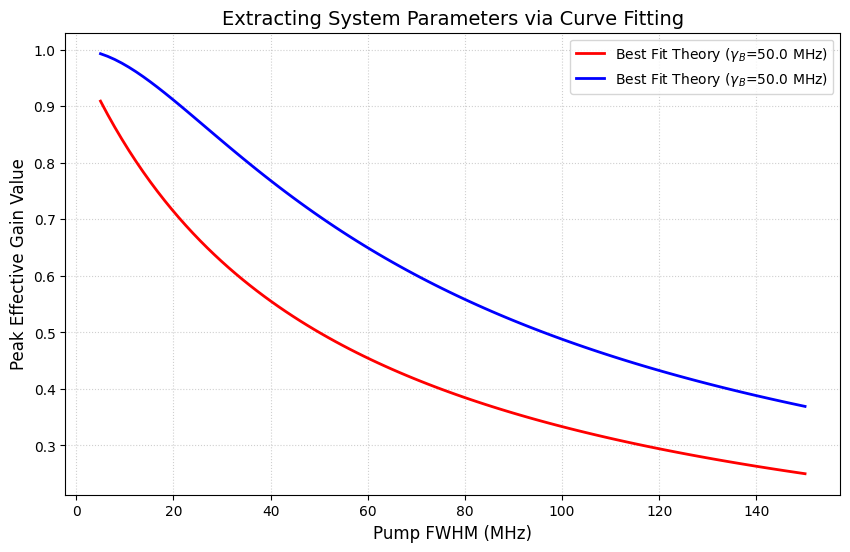

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erfc
import scipy.stats as stats
from scipy.optimize import curve_fit
np.random.seed(42)
Gamma_B=50.0
pump_w=np.linspace(5,150,100)
dif=np.linspace(-1500,1500,10000)
dnu=dif[1]-dif[0]
mono_gain=(Gamma_B/2)**2/((Gamma_B/2)**2+dif**2)
lor_conv=[]
gaus_conv=[]
for pump_wi in pump_w:
  lor_p = (1 / np.pi) * (pump_wi / 2) / ((pump_wi / 2)**2 + dif**2)
  sigma_p = pump_wi / (2 * np.sqrt(2 * np.log(2)))
  gaus_p = (1 / (sigma_p * np.sqrt(2 * np.pi))) * np.exp(-dif**2 / (2 * sigma_p**2))
  lor_conv.append(np.max(np.convolve(mono_gain, lor_p, mode='same') * dnu))
  gaus_conv.append(np.max(np.convolve(mono_gain, gaus_p, mode='same') * dnu))
s_nois=1
obs_lor=np.array(lor_conv)
obs_gaus=np.array(gaus_conv)
def lor_peak_skel(pump_w, gamma_fit, A):
  return A*(gamma_fit / (gamma_fit + pump_w))
def gaus_peak_skel(pump_w, gamma_fit, A):
  a = (gamma_fit / pump_w) * np.sqrt(np.log(2))
  b=np.tanh(-1.202*(a))+1
  return A * np.sqrt(np.pi) * a * np.exp(a**2) * erfc(a)
initial_guesses = [15.0, 0.5]
lor_pop,lor_cov=curve_fit(lor_peak_skel, pump_w, obs_lor, p0=initial_guesses, sigma=np.ones_like(pump_w)*s_nois)
gaus_pop,gaus_cov= curve_fit(gaus_peak_skel, pump_w, obs_gaus, p0=initial_guesses, sigma=np.ones_like(pump_w)*s_nois)
est_gamma_lor, est_A_lor = lor_pop
est_gamma_gau, est_A_gau = gaus_pop
err_gamma_lor = np.sqrt(lor_cov[0,0])
err_gamma_gau = np.sqrt(gaus_cov[0,0])
exp_lor_fit = lor_peak_skel(pump_w, est_gamma_lor, est_A_lor)
exp_gaus_fit = gaus_peak_skel(pump_w, est_gamma_gau, est_A_gau)
chi2_lor = np.sum(((obs_lor - exp_lor_fit) / s_nois) ** 2)
chi2_gau = np.sum(((obs_gaus - exp_gaus_fit) / s_nois) ** 2)
N = len(pump_w)
p = 2
deg_f=N-p
pval_lor = stats.chi2.sf(chi2_lor, deg_f)
pval_gaus=stats.chi2.sf(chi2_gau, deg_f)
print(f"Target True Value for Natural Linewidth (gamma_B): {Gamma_B} MHz\n")
print(f"Lorentzian Fit Results:")
print(f"  - Estimated gamma_B: {est_gamma_lor:.3f} ± {err_gamma_lor:.3f} MHz")
print(f"  - Estimated Scale A: {est_A_lor:.3f}")
print(f"  - Chi-Square / df:   {chi2_lor:.2f} / {deg_f} (Reduced: {chi2_lor/deg_f:.2f})")
print(f"  - Fit p-value:       {pval_lor:.4f}")
print(f"Gaussian Fit Results:")
print(f"  - Estimated gamma_B: {est_gamma_gau:.3f} ± {err_gamma_gau:.3f} MHz")
print(f"  - Estimated Scale A: {est_A_gau:.3f}")
print(f"  - Chi-Square / df:   {chi2_gau:.2f} / {deg_f} (Reduced: {chi2_gau/deg_f:.2f})")
print(f"  - Fit p-value:       {pval_gaus:.4f}")
plt.figure(figsize=(10, 6))
plt.plot(pump_w, exp_lor_fit, 'r-', linewidth=2, label=f'Best Fit Theory ($\gamma_B$={est_gamma_lor:.1f} MHz)')
plt.plot(pump_w, exp_gaus_fit, 'b-', linewidth=2, label=f'Best Fit Theory ($\gamma_B$={est_gamma_gau:.1f} MHz)')
plt.title('Extracting System Parameters via Curve Fitting', fontsize=14)
plt.xlabel('Pump FWHM (MHz)', fontsize=12)
plt.ylabel('Peak Effective Gain Value', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=10)
plt.show()
